# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 12s 0us/step
Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

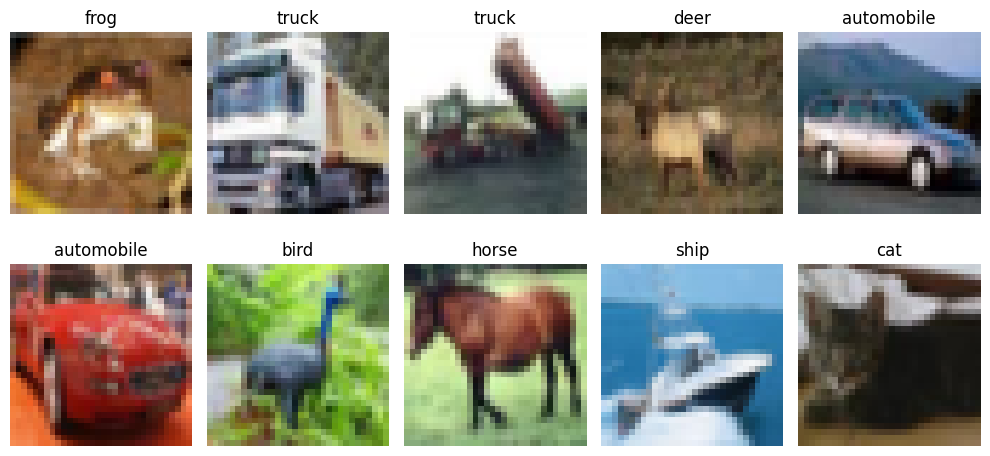

In [3]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [6]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [5]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 28s 38ms/step - accuracy: 0.2669 - loss: 1.9944 - val_accuracy: 0.3418 - val_loss: 1.8314
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 27s 39ms/step - accuracy: 0.3165 - loss: 1.8667 - val_accuracy: 0.3538 - val_loss: 1.7902
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 24s 34ms/step - accuracy: 0.3371 - loss: 1.8205 - val_accuracy: 0.3574 - val_loss: 1.7755
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 35ms/step - accuracy: 0.3501 - loss: 1.7801 - val_accuracy: 0.3744 - val_loss: 1.7511
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 27s 39ms/step - accuracy: 0.3610 - loss: 1.7516 - val_accuracy: 0.4086 - val_loss: 1.6792
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 31s 43ms/step - accuracy: 0.3672 - loss: 1.7407 - val_accuracy: 0.3916 - val_loss: 1.6986
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 25s 35ms/step - accuracy: 0.3750 - loss: 1.7165 - val_accuracy: 0.4142 - val_loss: 1.6658
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 23s 33ms/step - accuracy: 0.3791 - loss: 1.7122 - 

In [9]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.4322 - loss: 1.6238
ANN Test Accuracy: 0.43220001459121704


# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [7]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 105s 143ms/step - accuracy: 0.4682 - loss: 1.4941 - val_accuracy: 0.4984 - val_loss: 1.4223
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 94s 133ms/step - accuracy: 0.6030 - loss: 1.1301 - val_accuracy: 0.3874 - val_loss: 2.2466
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 103s 146ms/step - accuracy: 0.6665 - loss: 0.9536 - val_accuracy: 0.6646 - val_loss: 0.9734
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 95s 135ms/step - accuracy: 0.7107 - loss: 0.8296 - val_accuracy: 0.6606 - val_loss: 1.0183
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 101s 143ms/step - accuracy: 0.7431 - loss: 0.7299 - val_accuracy: 0.5976 - val_loss: 1.3814
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 100s 142ms/step - accuracy: 0.7719 - loss: 0.6540 - val_accuracy: 0.6880 - val_loss: 0.9413
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 94s 134ms/step - accuracy: 0.7934 - loss: 0.5852 - val_accuracy: 0.6770 - val_loss: 1.0882
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 98s 140ms/step - accuracy: 0.8118 - los

In [8]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.6760 - loss: 1.0708
CNN Test Accuracy: 0.6759999990463257


## 📈 Compare Learning Curves

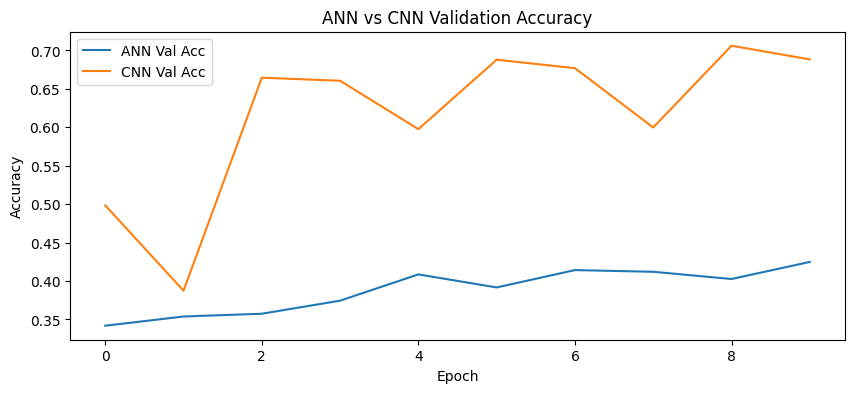

In [10]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [11]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

aug_history = aug_cnn_model.fit(
    x_train_norm,
    y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop]
)

aug_test_loss, aug_test_acc = aug_cnn_model.evaluate(x_test_norm, y_test)
print("Augmented CNN Test Accuracy:", aug_test_acc)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 77s 104ms/step - accuracy: 0.3765 - loss: 1.7135 - val_accuracy: 0.4750 - val_loss: 1.4263
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 70s 99ms/step - accuracy: 0.4699 - loss: 1.4753 - val_accuracy: 0.5478 - val_loss: 1.2460
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 80s 97ms/step - accuracy: 0.5111 - loss: 1.3789 - val_accuracy: 0.5892 - val_loss: 1.1573
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 70s 99ms/step - accuracy: 0.5315 - loss: 1.3244 - val_accuracy: 0.6002 - val_loss: 1.1120
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 68s 96ms/step - accuracy: 0.5482 - loss: 1.2785 - val_accuracy: 0.6118 - val_loss: 1.0799
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 70s 99ms/step - accuracy: 0.5576 - loss: 1.2515 - val_accuracy: 0.6004 - val_loss: 1.1229
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 99ms/step - accuracy: 0.5747 - loss: 1.2105 - val_accuracy: 0.6170 - val_loss: 1.0630
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 70s 99ms/step - accuracy: 0.5782 - loss: 1.1934 -

# 📊 Final Comparison Table

In [12]:
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN", "CNN + Augmentation"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc, aug_test_acc]
})
comparison


,Model,Test Accuracy
0,ANN,0.4322
1,CNN,0.6760
2,CNN + Augmentation,0.6498


# 🎓 Student Learning Tasks
Try these tasks after understanding the notebook:

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

# ✅ Conclusion
- **ANN works**, but ignores image structure
- **CNN extracts spatial features**, so it performs significantly better
- **Training strategies** like dropout, batch norm, and augmentation improve results
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**

In [ ]:
# Task 1: Improved ANN

improved_ann = models.Sequential([
    layers.Flatten(input_shape=(32,32,3)),
    layers.Dense(512, activation='relu'),
    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

improved_ann.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

improved_ann.fit(
    x_train_norm,
    y_train,
    epochs=20,
    validation_split=0.1,
    callbacks=[early_stop]
)

improved_ann_loss, improved_ann_acc = improved_ann.evaluate(
    x_test_norm, y_test
)

In [ ]:
# Task 2: Improved CNN

improved_cnn = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu',
                  input_shape=(32,32,3)),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

improved_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

improved_cnn.fit(
    x_train_norm,
    y_train,
    epochs=20,
    validation_split=0.1,
    callbacks=[early_stop]
)

improved_cnn_loss, improved_cnn_acc = improved_cnn.evaluate(
    x_test_norm, y_test
)

In [ ]:
comparison = pd.DataFrame({
    "Model": [
        "ANN",
        "Improved ANN",
        "CNN",
        "Improved CNN",
        "CNN + Augmentation"
    ],
    "Test Accuracy": [
        ann_test_acc,
        improved_ann_acc,
        cnn_test_acc,
        improved_cnn_acc,
        aug_test_acc
    ]
})

comparison